# Linear Classification: Logistic Regression and Support Vector Machines

Linear classification is a method of machine learning in which a linear combination of the features is used to predict outcomes. You can think of this as a line separating two groups of data points, though with many features this becomes a hyperplane.

Linear classification is typically faster and more efficient to run than nonlinear methods, often with similar performance. However, when features have significant overlap (ie multicollinearity), the model may struggle to find the best combination.


### Linear Classification Decision Function

The standard mathematical equation for a linear classifier is represented as:

$$f(x) = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

Where:
* **$\mathbf{x}$** is the input feature vector: $[x_1, x_2, \dots, x_n]^T$
* **$\mathbf{w}$** is the learned weight vector: $[w_1, w_2, \dots, w_n]^T$
* **$\mathbf{w}^T \mathbf{x}$** is the dot product ($w_1x_1 + w_2x_2 + \dots + w_nx_n$)
* **$b$** is the bias term (intercept)
* **$\text{sign}(\cdot)$** is the activation function mapping the score to a class:

$$\text{sign}(z) = \begin{cases} +1 & \text{if } z \geq 0 \\ -1 & \text{if } z < 0 \end{cases}$$

### Logistic Regression Classifier

In Logistic Regression, the linear combination of inputs ($\mathbf{w}^T \mathbf{x} + b$) is passed through a **sigmoid function** to map the output to a probability between 0 and 1.

The conditional probability of the positive class ($y=1$) given the features $\mathbf{x}$ is defined as:

$$P(y=1|\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

Where
 **$\sigma(z) = \frac{1}{1 + e^{-z}}$** is the Sigmoid (Logistic) activation function

### Decision Rule
To make a discrete class prediction ($\hat{y}$), a threshold of $0.5$ is typically applied to the probability:

$$\hat{y} = \begin{cases} 1 & \text{if } P(y=1|\mathbf{x}) \geq 0.5 \iff \mathbf{w}^T \mathbf{x} + b \geq 0 \\ 0 & \text{if } P(y=1|\mathbf{x}) < 0.5 \iff \mathbf{w}^T \mathbf{x} + b < 0 \end{cases}$$

### Loss function
The loss function (ie the error function) for Logistic Regression is known as log-loss or Binary Cross-Entropy (BCE) Loss:
$$L(\mathbf{w}) = \sum_{i=1}^n y_i \text{log}\left(\frac{1}{\sigma(\mathbf{w}^T \mathbf{x} + b)}\right) + \left(1-y_i\right)\text{log}\left(\frac{1}{1-\sigma(\mathbf{w}^T \mathbf{x} + b)}\right)  $$
This is what we aim to minimise when running our ML algorithm. 

### Optimisers
After each epoch, we use the gradient of the loss function to update the weights. There are a few ways to do this, the most common being stochastic gradient descent (SGD):

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla L(\mathbf{w}_t)$$

Actually running this in Python has the following steps:
1) Split the data into train and test and covert X_test, X_train, y_test, y_train into Torch tensors
2) Initialise the logistic regression model as a class
3) Define the loss function and optimiser
4) Run the model for the specified number of epochs:
    1. Predict y given the inputs X and the current model
    2. Calculate the loss for y_pred compared to y_train
    3. Compute the new gradient and update the weights

Let's try this using PyTorch and the Titanic data.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def split_and_preprocess_data(df):
    # Split X and y
    df = df.dropna()
    X = df.drop(columns=['Survived'])
    y = df['Survived'].values

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

    # Normalise the features using StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
    
    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor

In [44]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        # nn.Linear computes: z = Xw + b
        # input_dim is the number of features; output_dim is 1 for binary classification
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        # Apply the sigmoid function to map the linear output to a probability [0, 1]
        return torch.sigmoid(self.linear(x))

In [59]:
def run_logistic_regression(df, epochs=500, learning_rate=0.1,optimizer_type='SGD'):
    X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor = split_and_preprocess_data(df)
    _, num_features = X_train_tensor.shape
    
    # Initialise Model, Loss, and Optimiser
    model = LogisticRegression(input_dim=num_features)

    # BCE Loss is standard for binary classification
    criterion = nn.BCELoss() 
    if optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        raise ValueError("Unsupported optimizer type. Choose 'SGD' or 'Adam'.")

    # Training Loop
    loss_history = []
    for epoch in range(epochs):
        # Forward pass: Compute predicted probabilities
        y_pred = model(X_train_tensor)
        
        # Compute Loss
        loss = criterion(y_pred, y_train_tensor)

        # Backward pass: Clear old gradients and calculate new ones
        optimizer.zero_grad()
        loss.backward()
        
        # Update weights and bias
        optimizer.step()
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")
            
        loss_history.append(loss.item())

    # Plot loss curve
    plt.figure(figsize=(9, 5))
    plt.plot(range(1, epochs + 1), loss_history, color='steelblue', linewidth=2)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Cross-Entropy Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Evaluation
    with torch.no_grad():
        # Get final probabilities
        probabilities = model(X_train_tensor)
        # Classify as 1 if probability >= 0.5, else 0
        predictions = (probabilities >= 0.5).float()
        
        accuracy = (predictions == y_train_tensor).float().mean().item() * 100
        print("\n--- Final Results ---")
        print(f"Trained Weights: {model.linear.weight.data.tolist()}")
        print(f"Trained Bias: {model.linear.bias.data.item():.4f}")
        print(f"Training Accuracy: {accuracy:.2f}%")
        
    # Evaluate on the test set
    with torch.no_grad():
        test_probabilities = model(X_test_tensor)
        test_predictions = (test_probabilities >= 0.5).float()
        test_accuracy = (test_predictions == y_test_tensor).float().mean().item() * 100
        print(f"Test Set Accuracy: {test_accuracy:.2f}%")


Epoch [100/500], Loss: 0.4650
Epoch [200/500], Loss: 0.4575
Epoch [300/500], Loss: 0.4552
Epoch [400/500], Loss: 0.4544
Epoch [500/500], Loss: 0.4540


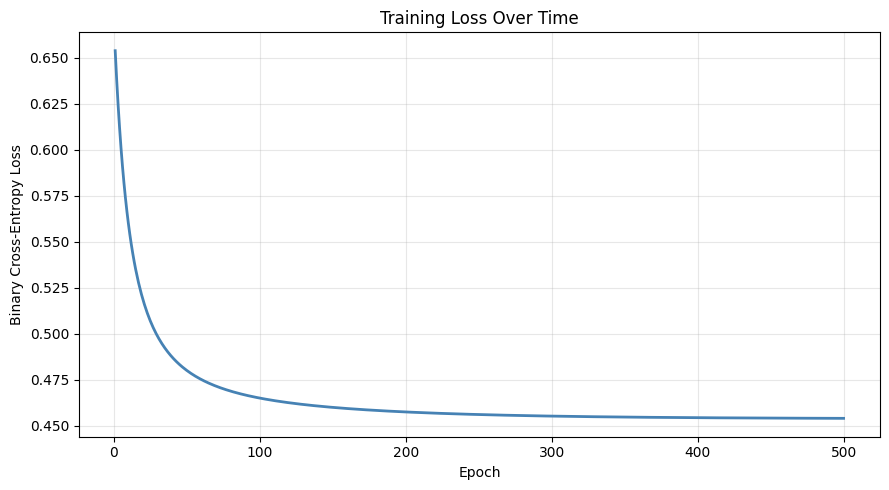


--- Final Results ---
Trained Weights: [[-0.9432967305183411, 1.0786367654800415, -0.47277799248695374, -0.252364844083786, 0.05357305705547333, 0.1880529373884201, 0.14723525941371918, 0.1740696281194687, -0.19751910865306854, -0.13147874176502228]]
Trained Bias: -0.6698
Training Accuracy: 79.61%
Test Set Accuracy: 83.15%


In [65]:
# Run on the dataset
# Read preprocessed data from the previous notebook
df = pd.read_csv('titanic/processed_train.csv')

run_logistic_regression(df)


Epoch [100/500], Loss: 0.4775
Epoch [200/500], Loss: 0.4665
Epoch [300/500], Loss: 0.4633
Epoch [400/500], Loss: 0.4621
Epoch [500/500], Loss: 0.4616


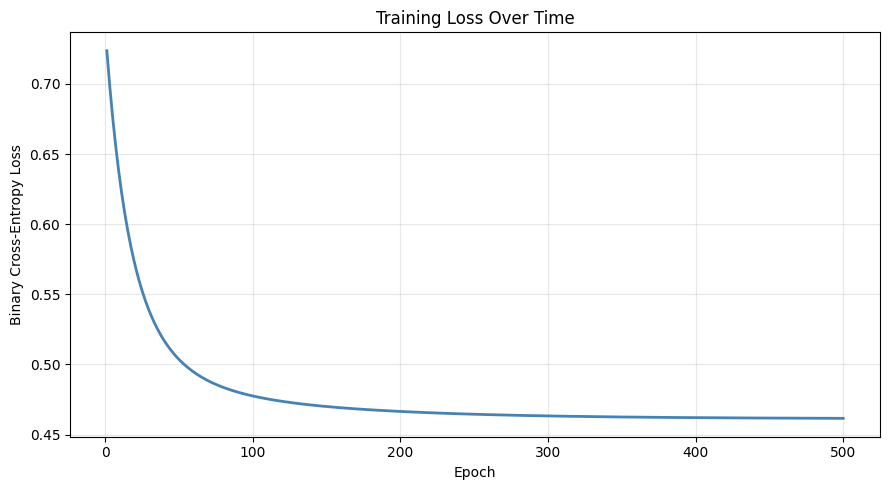


--- Final Results ---
Trained Weights: [[-0.9878580570220947, 1.1024224758148193, -0.47000446915626526, -0.04440561309456825, 0.205060675740242]]
Trained Bias: -0.6821
Training Accuracy: 78.62%
Test Set Accuracy: 83.71%


In [72]:
# Call the original model with a feature subset
subset_features = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
df_subset = df[subset_features].copy()

run_logistic_regression(df_subset)

Epoch [100/500], Loss: 0.4786
Epoch [200/500], Loss: 0.4669
Epoch [300/500], Loss: 0.4635
Epoch [400/500], Loss: 0.4621
Epoch [500/500], Loss: 0.4616


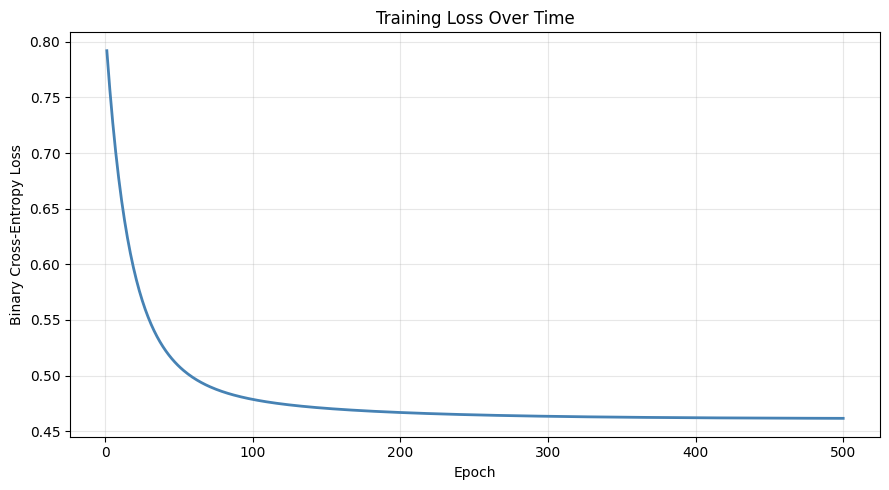


--- Final Results ---
Trained Weights: [[-0.9851862788200378, 1.101449966430664, -0.46966391801834106, -0.04141280800104141, 0.2048417180776596]]
Trained Bias: -0.6815
Training Accuracy: 78.62%
Test Set Accuracy: 83.71%


In [ ]:
from itertools import combinations

# Loop through different feature combinations and run the original model on each subset
candidate_features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'SibSp', 'Parch', 'rank']
subset_sizes = [3, 4]
max_combinations = 10  # Increase if you want to evaluate more combinations

combo_counter = 0
for k in subset_sizes:
    for combo in combinations(candidate_features, k):
        combo_counter += 1
        if combo_counter > max_combinations:
            break

        subset_cols = ['Survived'] + list(combo)
        df_subset = df[subset_cols].copy()

        print(f"\n=== Combination {combo_counter}: {combo} ===")
        run_logistic_regression(df_subset, epochs=200)

    if combo_counter > max_combinations:
        break

print(f"\nRan {min(combo_counter, max_combinations)} combinations.")

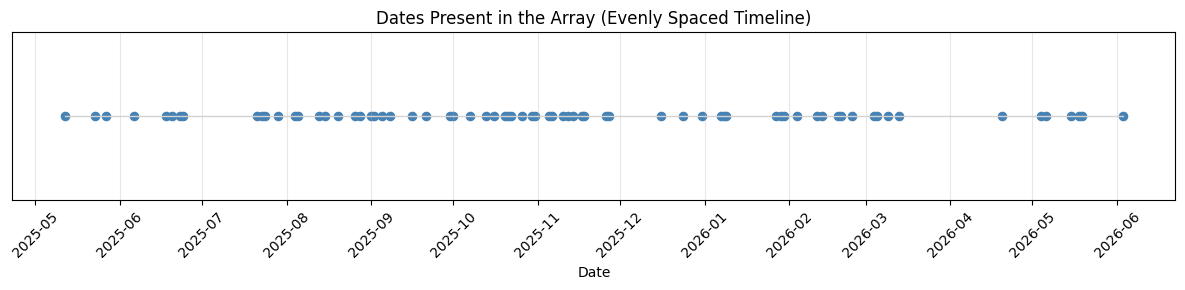

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

dates = ['2025-05-12','2025-05-23','2025-05-27','2025-06-06','2025-06-18','2025-06-20','2025-06-23','2025-06-24','2025-07-21','2025-07-23','2025-07-24','2025-07-29','2025-08-04','2025-08-05','2025-08-13','2025-08-15','2025-08-20','2025-08-26','2025-08-28','2025-09-01','2025-09-02','2025-09-05','2025-09-08','2025-09-16','2025-09-21','2025-09-30','2025-10-01','2025-10-07','2025-10-13','2025-10-16','2025-10-20','2025-10-21','2025-10-22','2025-10-26','2025-10-30','2025-10-31','2025-11-05','2025-11-06','2025-11-10','2025-11-12','2025-11-14','2025-11-17','2025-11-18','2025-11-26','2025-11-27','2025-12-16','2025-12-24','2025-12-31','2026-01-07','2026-01-08','2026-01-09','2026-01-27','2026-01-29','2026-01-30','2026-02-04','2026-02-11','2026-02-13','2026-02-19','2026-02-20','2026-02-24','2026-03-04','2026-03-05','2026-03-09','2026-03-13','2026-04-20','2026-05-04','2026-05-06','2026-05-15','2026-05-18','2026-05-19','2026-06-03']
dates2 = ['2025-04-06','2025-05-11','2025-06-11','2025-07-17','2025-08-25','2025-09-29','2025-11-06','2025-12-08','2026-01-14','2026-02-15','2026-04-04','2026-05-18']

# Convert both lists to datetime and build a complete daily timeline.
parsed_dates_1 = pd.to_datetime(dates)
parsed_dates_2 = pd.to_datetime(dates2)

timeline_start = min(parsed_dates_1.min(), parsed_dates_2.min())
timeline_end = max(parsed_dates_1.max(), parsed_dates_2.max())
all_dates = pd.date_range(timeline_start, timeline_end, freq='D')

# Mark dates from each list that appear in the timeline.
present_1 = pd.Series(False, index=all_dates)
present_1.loc[parsed_dates_1.normalize().unique()] = True

present_2 = pd.Series(False, index=all_dates)
present_2.loc[parsed_dates_2.normalize().unique()] = True

plt.figure(figsize=(12, 3))
plt.plot(all_dates, np.zeros(len(all_dates)), color='lightgray', linewidth=1)
plt.scatter(all_dates[present_1.values], np.zeros(present_1.sum()), color='steelblue', s=35, label='dates')
plt.scatter(all_dates[present_2.values], np.zeros(present_2.sum()), color='tomato', s=45, label='dates2')

plt.title('Dates Present in the Arrays (Evenly Spaced Timeline)')
plt.xlabel('Date')
plt.yticks([])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()